# BigMartSale Machime Learning project
Jamal Azizbeygi Boukani

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import scipy as scp

In [2]:
from bokeh.plotting import figure, output_file, show
output_file('BigMart.html')

# Data Proccessing

In [3]:
test_file='D:\project\Python\DataSets\BigMartSale\\test.csv'
train_file='D:\project\Python\DataSets\BigMartSale\\train.csv'
df_test=pd.read_csv(test_file)
df_train=pd.read_csv(train_file)

In [4]:
df_test.info()
df_train.info()
print("df_test.shape",df_test.shape)
print("df_train.shape",df_train.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 colu

In [5]:
df_train['source']='df_train'
df_test['source']='df_test'
df = pd.concat([df_train, df_test],ignore_index=True)
print(df_train.shape,df_test.shape, df.shape)
#df=pd.concat([df_test,df_train])
#df.info()

(8523, 13) (5681, 12) (14204, 13)


In [6]:
df.apply(lambda x : len(x.unique()))

Item_Identifier               1559
Item_Weight                    416
Item_Fat_Content                 5
Item_Visibility              13006
Item_Type                       16
Item_MRP                      8052
Outlet_Identifier               10
Outlet_Establishment_Year        9
Outlet_Size                      4
Outlet_Location_Type             3
Outlet_Type                      4
Item_Outlet_Sales             3494
source                           2
dtype: int64

In [11]:
#del df_test
#del df_train
df.shape

(14204, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                11765 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                10188 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usag

In [13]:
df['Item_Outlet_Sales'].describe()

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='Item_Outlet_Sales', ylabel='Density'>

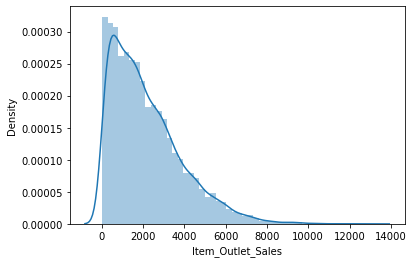

In [14]:
sns.distplot(df['Item_Outlet_Sales'])

## Check Null value

In [15]:
df.apply(lambda x: sum(x.isnull()))

Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [16]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [18]:
from sklearn.impute import SimpleImputer

In [19]:
si = SimpleImputer(missing_values=np.nan, strategy='mean')
si.fit(df[:, 1:])
df[:, 1:] = si.transform(df[:, 1:])

TypeError: '(slice(None, None, None), slice(1, None, None))' is an invalid key

In [13]:
from sklearn.preprocessing import LabelEncoder

In [18]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,11765.000000,14204.000000,14204.000000,14204.000000,8523.000000
mean,12.792854,0.065953,141.004977,1997.830681,2181.288914
std,4.652502,0.051459,62.086938,8.371664,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.710000,0.027036,94.012000,1987.000000,834.247400
50%,12.600000,0.054021,142.247000,1999.000000,1794.331000
75%,16.750000,0.094037,185.855600,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [19]:
#Filter categorical variables
categorical_columns = [x for x in df.dtypes.index if df.dtypes[x]=='object']
#Exclude ID cols and source:
categorical_columns = [x for x in categorical_columns if x not in ['Item_Identifier','Outlet_Identifier','source']]
#Print frequency of categories
for col in categorical_columns:
    print('\nFrequency of Categories for varible %s'%col)
    print(df[col].value_counts())


Frequency of Categories for varible Item_Fat_Content
Low Fat    8485
Regular    4824
LF          522
reg         195
low fat     178
Name: Item_Fat_Content, dtype: int64

Frequency of Categories for varible Item_Type
Fruits and Vegetables    2013
Snack Foods              1989
Household                1548
Frozen Foods             1426
Dairy                    1136
Baking Goods             1086
Canned                   1084
Health and Hygiene        858
Meat                      736
Soft Drinks               726
Breads                    416
Hard Drinks               362
Others                    280
Starchy Foods             269
Breakfast                 186
Seafood                    89
Name: Item_Type, dtype: int64

Frequency of Categories for varible Outlet_Size
Medium    4655
Small     3980
High      1553
Name: Outlet_Size, dtype: int64

Frequency of Categories for varible Outlet_Location_Type
Tier 3    5583
Tier 2    4641
Tier 1    3980
Name: Outlet_Location_Type, dtype: int64

F

# Imputing Missing Value

In [21]:
df.isna().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
source                       0
dtype: int64

In [22]:
for i in df.columns:
    if(df[i].dtype==object and (df[i].isnull().sum())):# It shows that our futurs is Catogorical
#         print(df[i].isnull().sum())
        df[i].fillna(df[i].mode().iloc[0],inplace=True)
    elif (df[i].dtype=='float' and (df[i].isnull().sum())):
        df[i].fillna(df[i].median(),inplace=True)

In [23]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
source                       0
dtype: int64

In [24]:
#df.drop(['Item_Identifier'], axis=1, inplace=True)
#df.info()
df.drop(['Item_Type','Item_Identifier'],axis=1,inplace=True)
train = df.loc[df['source']=='df_train']
test = df.loc[df['source']=='df_test']

train.drop('source',axis=1,inplace=True)
test.drop(['source','Item_Outlet_Sales'],axis=1,inplace=True)


C:\ProgramData\Anaconda3\lib\site-packages\pandas\core\frame.py:4906: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().drop(


# Data Labeling
when we have object these objects have to labeled with labeling to peer number like yes to be 1 and no 0./
Addtionally, for this aim use from sklearn.preprocessing import LabelEncoder

In [25]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Weight                14204 non-null  float64
 1   Item_Fat_Content           14204 non-null  object 
 2   Item_Visibility            14204 non-null  float64
 3   Item_MRP                   14204 non-null  float64
 4   Outlet_Identifier          14204 non-null  object 
 5   Outlet_Establishment_Year  14204 non-null  int64  
 6   Outlet_Size                14204 non-null  object 
 7   Outlet_Location_Type       14204 non-null  object 
 8   Outlet_Type                14204 non-null  object 
 9   Item_Outlet_Sales          14204 non-null  float64
 10  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 1.2+ MB


In [28]:
for i in df.columns:
    if(df[i].dtype==object):
        df[i]=le.fit_transform(df[i])

In [31]:
df.head(10)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
0,9.300,1,0.016047,249.8092,9,1999,1,0,1,3735.1380,1
1,5.920,2,0.019278,48.2692,3,2009,1,2,2,443.4228,1
2,17.500,1,0.016760,141.6180,9,1999,1,0,1,2097.2700,1
3,19.200,2,0.000000,182.0950,0,1998,1,2,0,732.3800,1
4,8.930,1,0.000000,53.8614,1,1987,0,2,1,994.7052,1
5,10.395,2,0.000000,51.4008,3,2009,1,2,2,556.6088,1
6,13.650,2,0.012741,57.6588,1,1987,0,2,1,343.5528,1
7,12.600,1,0.127470,107.7622,5,1985,1,2,3,4022.7636,1
8,16.200,2,0.016687,96.9726,7,2002,1,1,1,1076.5986,1
9,19.200,2,0.094450,187.8214,2,2007,1,1,1,4710.5350,1


# Scaling Proccess
Data between 0 and 1
Max is:1 and Min is:0

In [26]:
for i in df.columns:
    df[i]=((df[i]-df[i].min())/(df[i].max()-df[i].min()))

In [27]:
df.head(5)

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
0,0.282525,0.25,0.048866,0.927507,1.000000,0.583333,0.5,0.0,0.333333,0.283587,1.0
1,0.081274,0.50,0.058705,0.072068,0.333333,1.000000,0.5,1.0,0.666667,0.031419,1.0
2,0.770765,0.25,0.051037,0.468288,1.000000,0.583333,0.5,0.0,0.333333,0.158115,1.0
3,0.871986,0.50,0.000000,0.640093,0.000000,0.541667,0.5,1.0,0.000000,0.053555,1.0
4,0.260494,0.25,0.000000,0.095805,0.111111,0.083333,0.0,1.0,0.333333,0.073651,1.0


# Create Model


In [28]:
from sklearn.model_selection import train_test_split
x=df.drop(['Item_Outlet_Sales','source'],axis=1)# Create our futures
y=df['Item_Outlet_Sales']# Create our Target
x_train, x_test, y_train, y_test=train_test_split(x,y, random_state=10, test_size=0.2)

C:\ProgramData\Anaconda3\lib\importlib\_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


# Train population is 80% of all and test is 20%

In [29]:
print("x_train population is: ",(len(x_train)/len(x))*100)
print("y_train population is: ",(len(y_train)/len(y))*100)
print("x_test population is: ",(len(x_test)/len(x))*100)
print("y_test population is: ",(len(y_test)/len(y))*100)

x_train population is:  79.99859194593071
y_train population is:  79.99859194593071
x_test population is:  20.001408054069277
y_test population is:  20.001408054069277


In [30]:
print("type(x)", type(x))
print("type(y)", type(y))
print(len(y))
print(len(x.iloc[0]))

type(x) <class 'pandas.core.frame.DataFrame'>
type(y) <class 'pandas.core.series.Series'>
14204
9


In [31]:
import tensorflow as ts
import keras
from keras.models import Sequential
from keras.layers import InputLayer,Dense

In [32]:
# defining input neurons
input_neurons = x_train.shape[1]
print(input_neurons)
# define number of output neurons
output_neurons = 1
# number of hidden layers and hidden neurons

# It is a hyperparameter and we can pick the hidden layers and hidden neurons on our own
# define hidden layers and neuron in each layer
# I checke many times, I would like to use 3 layers which had conviniant evoloation after loss function
number_of_hidden_layers = 2
neuron_hidden_layer_1 = 10
neuron_hidden_layer_2 = 5


9


In [33]:
model=Sequential()
model.add(InputLayer(input_shape=(input_neurons,)))
model.add(Dense(units=neuron_hidden_layer_1,activation='relu'))
model.add(Dense(units=neuron_hidden_layer_2,activation='relu'))
model.add(Dense(units=output_neurons,activation='linear'))

# Compiling the model (defining loss function, optimizer)

In [34]:
# compiling the model

# loss as mse,rmse since we have regresion problem
# defining the optimizer as adam
# Evaluation metric as mse,mae
model.compile(loss='mse',optimizer='adam',metrics=['mean_absolute_error'])

# Training the model

In [35]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                100       
                                                                 
 dense_1 (Dense)             (None, 5)                 55        
                                                                 
 dense_2 (Dense)             (None, 1)                 6         
                                                                 
Total params: 161
Trainable params: 161
Non-trainable params: 0
_________________________________________________________________


In [36]:
model_history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=50)

Epoch 1/50
356/356 [==============================] - 4s 6ms/step - loss: 0.0518 - mean_absolute_error: 0.1507 - val_loss: 0.0114 - val_mean_absolute_error: 0.0749
Epoch 2/50
356/356 [==============================] - 2s 5ms/step - loss: 0.0089 - mean_absolute_error: 0.0688 - val_loss: 0.0090 - val_mean_absolute_error: 0.0692
Epoch 3/50
356/356 [==============================] - 2s 5ms/step - loss: 0.0080 - mean_absolute_error: 0.0656 - val_loss: 0.0084 - val_mean_absolute_error: 0.0665
Epoch 4/50
356/356 [==============================] - 2s 5ms/step - loss: 0.0076 - mean_absolute_error: 0.0640 - val_loss: 0.0081 - val_mean_absolute_error: 0.0632
Epoch 5/50
356/356 [==============================] - 2s 5ms/step - loss: 0.0073 - mean_absolute_error: 0.0630 - val_loss: 0.0079 - val_mean_absolute_error: 0.0652
Epoch 6/50
356/356 [==============================] - 2s 5ms/step - loss: 0.0072 - mean_absolute_error: 0.0625 - val_loss: 0.0077 - val_mean_absolute_error: 0.0629
Epoch 7/50
356/3

# 6. Evaluating model performance on validation set


In [37]:
model_predictions=model.predict(x_test)
#model_predictions=model.predict_classes(x_test)
model_predictions

array([[0.11468805],
       [0.1385845 ],
       [0.1829781 ],
       ...,
       [0.08879257],
       [0.1604    ],
       [0.1575374 ]], dtype=float32)

In [38]:
# calculating the accuracy on validation set by r2_score
# As this model is regression so r2_score is compitable than other evolation mesurments.
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
print("mean_absolute_error",mean_absolute_error(y_test,model_predictions))
print("r2_score",r2_score(y_test,model_predictions))

mean_absolute_error 0.06285253866230027
r2_score 0.35585559004196854


# Visualizing the model performance


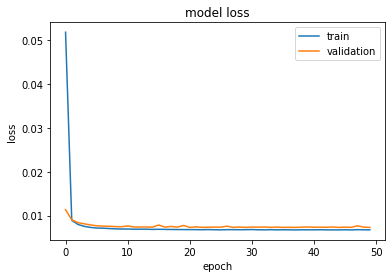

In [39]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

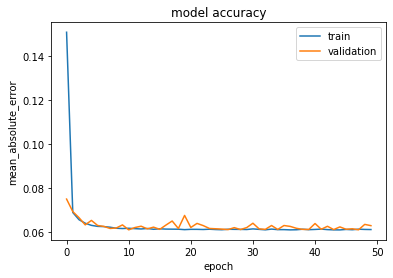

In [40]:
# summarize history for accuracy
plt.plot(model_history.history['mean_absolute_error'])
plt.plot(model_history.history['val_mean_absolute_error'])
plt.title('model accuracy')
plt.ylabel('mean_absolute_error')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()


In [41]:
model.save('D:\project\Python\DataSets\BigMartSales3\\')

INFO:tensorflow:Assets written to: D:\project\Python\DataSets\BigMartSales3\assets


In [42]:
del model

In [43]:
from keras.models import load_model
loaded_model=load_model('D:\project\Python\DataSets\BigMartSales3\\')
loaded_model.predict(x_test)

array([[0.11468805],
       [0.1385845 ],
       [0.1829781 ],
       ...,
       [0.08879257],
       [0.1604    ],
       [0.1575374 ]], dtype=float32)